In [1]:
import subprocess, os, shutil

REPO_URL = "https://github.com/safety-research/legibility.git"
REPO_DIR = "/workspace/18-4-2026"
EXP_DIR = os.path.join(REPO_DIR, "experiments", "2026", "15-4-2026")

# Clone or pull latest (fetch + reset to ensure we have the newest commit)
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)


# Download results data from HuggingFace (too large for git)
from huggingface_hub import hf_hub_download
RESULTS_DIR = os.path.join(EXP_DIR, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)
for fname in ["classifications.json", "cot_texts.json"]:
    target = os.path.join(RESULTS_DIR, fname)
    if not os.path.exists(target):
        print(f"Downloading {fname} from HuggingFace...")
        hf_hub_download(
            repo_id="Noddybear/legibility-data",
            filename=f"results/{fname}",
            repo_type="dataset",
            local_dir=EXP_DIR,
        )
    else:
        print(f"CACHED: {fname}")

# Install dependencies
req_path = os.path.join(EXP_DIR, "requirements.txt")
if os.path.exists(req_path):
    subprocess.run(["pip", "install", "-q", "-r", req_path], check=True)
else:
    print(f"WARNING: {req_path} not found, skipping pip install")

# Set working directory so Path.cwd().parent resolves to experiment root
os.chdir(os.path.join(EXP_DIR, "notebooks"))

HEAD is now at 740a19f Update Phase 2 code for larger dataset and add NB10 perplexity analysis


In [2]:
# !rm /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/reader_analysis_results.json
# !rm /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/d_c2_success_probe.png

# NB7: Reader-Side Activation Analysis (Experiment D)

**CPU notebook** (~15 min). Analyzes R2 activations to understand what happens
inside the reader when it succeeds vs fails at C2 crossfill.

Split R2 activations by C2 outcome and legibility class. Train probe to predict
C2 success. Include foreignness covariate. Report AUROC with and without foreignness.

**Requires:** NB2 outputs (`activations/R2_last_token/`, `activations/R2_cot_boundary/`)

In [ ]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import (
    load_activations, load_distributional_shift_scores, train_binary_probe,
    permutation_test, plot_layer_probe_curve, bootstrap_ci_metric,
    ACTIVATIONS_DIR, PHASE2_RESULTS_DIR,
)

PHASE2_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# Checkpoint: check if final output already exists
_output_path = PHASE2_RESULTS_DIR / 'reader_analysis_results.json'
if _output_path.exists():
    import json as _json
    with open(_output_path) as _f:
        _saved = _json.load(_f)
    print(f"CACHED: {_output_path} exists.")
    for key in _saved:
        n_layers = len(_saved[key]) if isinstance(_saved[key], dict) else 'N/A'
        print(f"  {key}: {n_layers} layers")
    print("Delete this file and re-run to recompute.")

In [5]:
# Load R2 activations and metadata
r2_last = load_activations(ACTIVATIONS_DIR / "R2_last_token")
r2_boundary = load_activations(ACTIVATIONS_DIR / "R2_cot_boundary")

with open(ACTIVATIONS_DIR / "R2_last_token" / "metadata.json") as f:
    r2_meta = json.load(f)

r2_labels = np.array(r2_meta['labels'])  # 1=C2 success, 0=C2 failure
r2_sample_meta = r2_meta['sample_metadata']

print(f"R2 activations: {len(r2_labels)} samples, layers={sorted(r2_last.keys())}")
print(f"C2 success rate: {r2_labels.mean():.1%}")

# Check by legibility class
for label in ['ANSWER_LEAKED', 'REASONING_LEGIBLE', 'ILLEGIBLE']:
    mask = np.array([m['label'] == label for m in r2_sample_meta])
    if mask.sum() > 0:
        print(f"  {label}: n={mask.sum()}, C2 success={r2_labels[mask].mean():.1%}")

R2 activations: 666 samples, layers=[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 76, 79]
C2 success rate: 51.4%
  ANSWER_LEAKED: n=278, C2 success=73.7%
  REASONING_LEGIBLE: n=100, C2 success=78.0%
  ILLEGIBLE: n=288, C2 success=20.5%


=== Probe: Predict C2 Success (excluding ANSWER_LEAKED) ===
Non-leaked samples: 388 (C2 success=137, failure=251)
  Layer   0: AUROC=0.500 CI=(0.5, 0.5)
  Layer   4: AUROC=0.575 CI=(0.5431587301587302, 0.6072633053221288)
  Layer   8: AUROC=0.602 CI=(0.5715026455026455, 0.6319309056956117)
  Layer  12: AUROC=0.612 CI=(0.5967048449009233, 0.6272592592592592)
  Layer  16: AUROC=0.606 CI=(0.5789685652038593, 0.6427675070028012)
  Layer  20: AUROC=0.638 CI=(0.5834859088079676, 0.7098543417366947)
  Layer  24: AUROC=0.653 CI=(0.6015279593318809, 0.7073015873015873)
  Layer  28: AUROC=0.638 CI=(0.5859034132171388, 0.6906349206349206)
  Layer  32: AUROC=0.674 CI=(0.6329173150741778, 0.7165555555555555)
  Layer  36: AUROC=0.687 CI=(0.6333449527959332, 0.7370423539786284)
  Layer  40: AUROC=0.683 CI=(0.6252962962962962, 0.7368876439464674)
  Layer  44: AUROC=0.672 CI=(0.6145185185185186, 0.7229629629629629)
  Layer  48: AUROC=0.691 CI=(0.6285984023238926, 0.7444444444444445)
  Layer  52: AUROC=

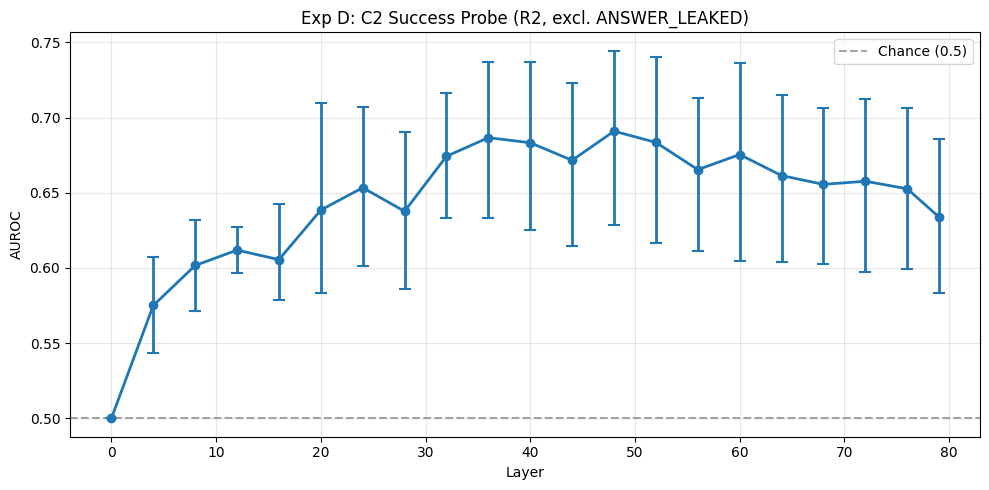

In [6]:
# Probe 1: Predict C2 success from last-token activations
# IMPORTANT: Exclude ANSWER_LEAKED samples -- these trivially succeed at C2
# and would inflate probe AUROC. Only use REASONING_LEGIBLE + ILLEGIBLE.
print("=== Probe: Predict C2 Success (excluding ANSWER_LEAKED) ===")

non_leaked_mask = np.array([
    m['label'] in ('REASONING_LEGIBLE', 'ILLEGIBLE')
    for m in r2_sample_meta
])
non_leaked_labels = r2_labels[non_leaked_mask]

print(f"Non-leaked samples: {non_leaked_mask.sum()} "
      f"(C2 success={non_leaked_labels.sum()}, failure={(1-non_leaked_labels).sum()})")

n_min_class = min(non_leaked_labels.sum(), (1 - non_leaked_labels).sum())
if n_min_class < 5:
    print(f"WARNING: Min class has only {n_min_class} samples -- probe may be unreliable")

c2_success_results = {}
for layer_idx in sorted(r2_last.keys()):
    features = r2_last[layer_idx][non_leaked_mask]
    if n_min_class < 5:
        print(f"  Layer {layer_idx}: skipping (min class={n_min_class})")
        continue
    
    result = train_binary_probe(features, non_leaked_labels, n_splits=min(5, n_min_class))
    c2_success_results[layer_idx] = result
    print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")

if c2_success_results:
    fig, ax = plot_layer_probe_curve(
        c2_success_results,
        title='Exp D: C2 Success Probe (R2, excl. ANSWER_LEAKED)',
        save_path=str(PHASE2_RESULTS_DIR / 'd_c2_success_probe.png'),
    )
    plt.show()

In [7]:
# Probe 2: Predict C2 success from CoT boundary activations
# Exclude ANSWER_LEAKED (same filter as Probe 1)
print("=== Probe: Predict C2 Success (CoT boundary, excl. ANSWER_LEAKED) ===")

boundary_results = {}
for layer_idx in sorted(r2_boundary.keys()):
    features = r2_boundary[layer_idx][non_leaked_mask]
    if n_min_class < 5:
        continue
    
    result = train_binary_probe(features, non_leaked_labels, n_splits=min(5, n_min_class))
    boundary_results[layer_idx] = result
    print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")

=== Probe: Predict C2 Success (CoT boundary, excl. ANSWER_LEAKED) ===
  Layer   0: AUROC=0.471 CI=(0.4090547774665422, 0.542526455026455)
  Layer   4: AUROC=0.498 CI=(0.4337929245772384, 0.583125531694159)
  Layer   8: AUROC=0.499 CI=(0.4298933499325656, 0.5729629629629629)
  Layer  12: AUROC=0.502 CI=(0.4473110281149496, 0.5608518518518518)
  Layer  16: AUROC=0.568 CI=(0.5046551509492685, 0.632504824151883)
  Layer  20: AUROC=0.589 CI=(0.5502743023135179, 0.6400624338624339)
  Layer  24: AUROC=0.594 CI=(0.5502380952380952, 0.6471849128540306)
  Layer  28: AUROC=0.613 CI=(0.5896789086004772, 0.6366752775184147)
  Layer  32: AUROC=0.642 CI=(0.6040329909741674, 0.6786132508558979)
  Layer  36: AUROC=0.661 CI=(0.6141315489158626, 0.7077301587301588)
  Layer  40: AUROC=0.616 CI=(0.5834285714285714, 0.6489756198775807)
  Layer  44: AUROC=0.628 CI=(0.5867241415084552, 0.6678518518518517)
  Layer  48: AUROC=0.652 CI=(0.6141693121693121, 0.6898124286751738)
  Layer  52: AUROC=0.636 CI=(0.59543

In [8]:
# Probe 3: Predict legibility class from R2 activations
# (excluding ANSWER_LEAKED)
print("=== Probe: Predict Legibility from R2 Activations ===")

leg_mask = np.array([
    m['label'] in ('REASONING_LEGIBLE', 'ILLEGIBLE')
    for m in r2_sample_meta
])
leg_labels = np.array([
    1 if m['label'] == 'REASONING_LEGIBLE' else 0
    for m in r2_sample_meta
])

print(f"Non-leaked samples: {leg_mask.sum()} "
      f"(legible={leg_labels[leg_mask].sum()}, illegible={(1-leg_labels[leg_mask]).sum()})")

if leg_mask.sum() >= 20:
    legibility_from_reader_results = {}
    for layer_idx in sorted(r2_last.keys()):
        features = r2_last[layer_idx][leg_mask]
        labels = leg_labels[leg_mask]
        
        result = train_binary_probe(features, labels, n_splits=5)
        legibility_from_reader_results[layer_idx] = result
        print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")
else:
    print("Insufficient non-leaked samples for this analysis")
    legibility_from_reader_results = {}

=== Probe: Predict Legibility from R2 Activations ===
Non-leaked samples: 388 (legible=100, illegible=288)
  Layer   0: AUROC=0.500 CI=(0.5, 0.5)
  Layer   4: AUROC=0.590 CI=(0.5312885662431942, 0.6530580762250454)
  Layer   8: AUROC=0.606 CI=(0.5317483363581367, 0.6863082274652147)
  Layer  12: AUROC=0.619 CI=(0.5558560193587417, 0.6870901391409558)
  Layer  16: AUROC=0.643 CI=(0.582940108892922, 0.702486388384755)
  Layer  20: AUROC=0.636 CI=(0.5763762855414398, 0.6987507562008469)
  Layer  24: AUROC=0.633 CI=(0.568366606170599, 0.6929038112522686)
  Layer  28: AUROC=0.648 CI=(0.5920084694494858, 0.7105928614640049)
  Layer  32: AUROC=0.673 CI=(0.6238173018753781, 0.7372572595281308)
  Layer  36: AUROC=0.706 CI=(0.6551724137931034, 0.7593103448275861)
  Layer  40: AUROC=0.679 CI=(0.6040139140955839, 0.7542679975801573)
  Layer  44: AUROC=0.686 CI=(0.6215366001209921, 0.7496612220205687)
  Layer  48: AUROC=0.687 CI=(0.6194494857834242, 0.754216575922565)
  Layer  52: AUROC=0.679 CI=(0

In [ ]:
# R2 perplexity covariate analysis
ds_scores = load_distributional_shift_scores()

# Get R2 perplexity for each sample (single key, no reader loop)
r2_perplexity = []
for m in r2_sample_meta:
    key = (m['sample_id'], m['generator_id'], m['epoch'], 'R2')
    entry = ds_scores.get(key)
    r2_perplexity.append(entry['reader_perplexity'] if entry else np.nan)
r2_perplexity = np.array(r2_perplexity, dtype=float)

valid_p = np.isfinite(r2_perplexity)
print(f"R2 perplexity available: {valid_p.sum()}/{len(r2_perplexity)}")

if valid_p.sum() >= 20 and c2_success_results:
    # Compare C2 success probe with vs without R2 perplexity
    best_layer = max(c2_success_results, key=lambda k: c2_success_results[k]['auroc'])
    features_base = r2_last[best_layer][valid_p]
    labels_p = r2_labels[valid_p]
    perplexity_p = r2_perplexity[valid_p]

    # Without R2 perplexity
    r_no_p = train_binary_probe(features_base, labels_p)
    print(f"Without R2 perplexity: AUROC={r_no_p['auroc']:.3f} CI={r_no_p['auroc_ci']}")

    # With R2 perplexity
    features_with_p = np.column_stack([features_base, perplexity_p.reshape(-1, 1)])
    r_with_p = train_binary_probe(features_with_p, labels_p)
    print(f"With R2 perplexity:    AUROC={r_with_p['auroc']:.3f} CI={r_with_p['auroc_ci']}")

    # R2 perplexity only
    r_p_only = train_binary_probe(perplexity_p.reshape(-1, 1), labels_p)
    print(f"R2 perplexity only:    AUROC={r_p_only['auroc']:.3f} CI={r_p_only['auroc_ci']}")

In [10]:
# Save results
def clean_results(d):
    return {int(k): {kk: vv for kk, vv in v.items() if kk not in ('probe_model', 'scaler')}
            for k, v in d.items()}

output = {
    'c2_success_probe': clean_results(c2_success_results),
    'boundary_probe': clean_results(boundary_results),
    'legibility_from_reader': clean_results(legibility_from_reader_results),
}
with open(PHASE2_RESULTS_DIR / 'reader_analysis_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)
print(f"Saved to {PHASE2_RESULTS_DIR / 'reader_analysis_results.json'}")

Saved to /workspace/18-4-2026/experiments/2026/15-4-2026/results/phase2/reader_analysis_results.json
